In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
#  style
# ------------------------
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# ------------------------
# LOAD data
# ------------------------
df = pd.read_csv(r"D:\new projects\datashit\jobs.csv")
print("CSV Loaded Successfully!")
print(df.head())




CSV Loaded Successfully!
   SL              Category                              Job Title  \
0   1              Teaching                          Lead Teaching   
1   2         AI Researcher       AI Researcher - Bangladesh Based   
2   3           QA Engineer              QA Engineer - Dhaka Based   
3   4  Full Stack Developer  Full Stack Developer - Java Developer   
4   5     Backend Developer               Senior Backend Developer   

                                             Skills Experience  \
0       Express.js, Computer Vision, Angular, Swift  1 year(s)   
1             Linux, Terraform, Python, NLP, Spring  3 year(s)   
2                                  AWS, Vue.js, Git  3 year(s)   
3  Scikit-learn, HTML, Security, Kubernetes, Spring  1 year(s)   
4                           Bash, Flask, Linux, SQL  4 year(s)   

                          Salary  \
0  Tk. 15,000 - 35,000 (Monthly)   
1  Tk. 30,000 - 50,000 (Monthly)   
2  Tk. 50,000 - 60,000 (Monthly)   
3  BDT 15,000

In [3]:
def parse_salary(text):
    if pd.isna(text):
        return np.nan
    text = str(text).lower()
    text = re.sub(r'[,$€£৳]', '', text)
    text = text.replace('tk.', '').replace('tk', '').replace('bdt', '').replace('usd', '').replace('aud', '')
    text = re.sub(r'(\d+)k', lambda m: str(int(m.group(1)) * 1000), text)
    nums = re.findall(r'\d+', text)
    if not nums:
        return np.nan
    nums = list(map(int, nums))
    if len(nums) >= 2:
        return (nums[0] + nums[1]) / 2
    return nums[0]

df['SalaryNum'] = df['Salary'].apply(parse_salary)

# ------------------------
# list
# ------------------------
skill_list = []
for skills in df['Skills'].dropna():
    for skill in skills.split(','):
        skill_list.append(skill.strip().lower())
skill_series = pd.Series(skill_list)


def draw_bar_chart(x, y, title, xlabel, ylabel, palette='viridis'):
    plt.figure(figsize=(12,6))
    ax = sns.barplot(x=x, y=y, hue=y, dodge=False, palette=palette, legend=False)
    plt.title(title, fontsize=16, weight='bold')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    
    # Add value labels
    for i, v in enumerate(x):
        ax.text(v + max(x)*0.01, i, f"{v:,.0f}", color='black', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()



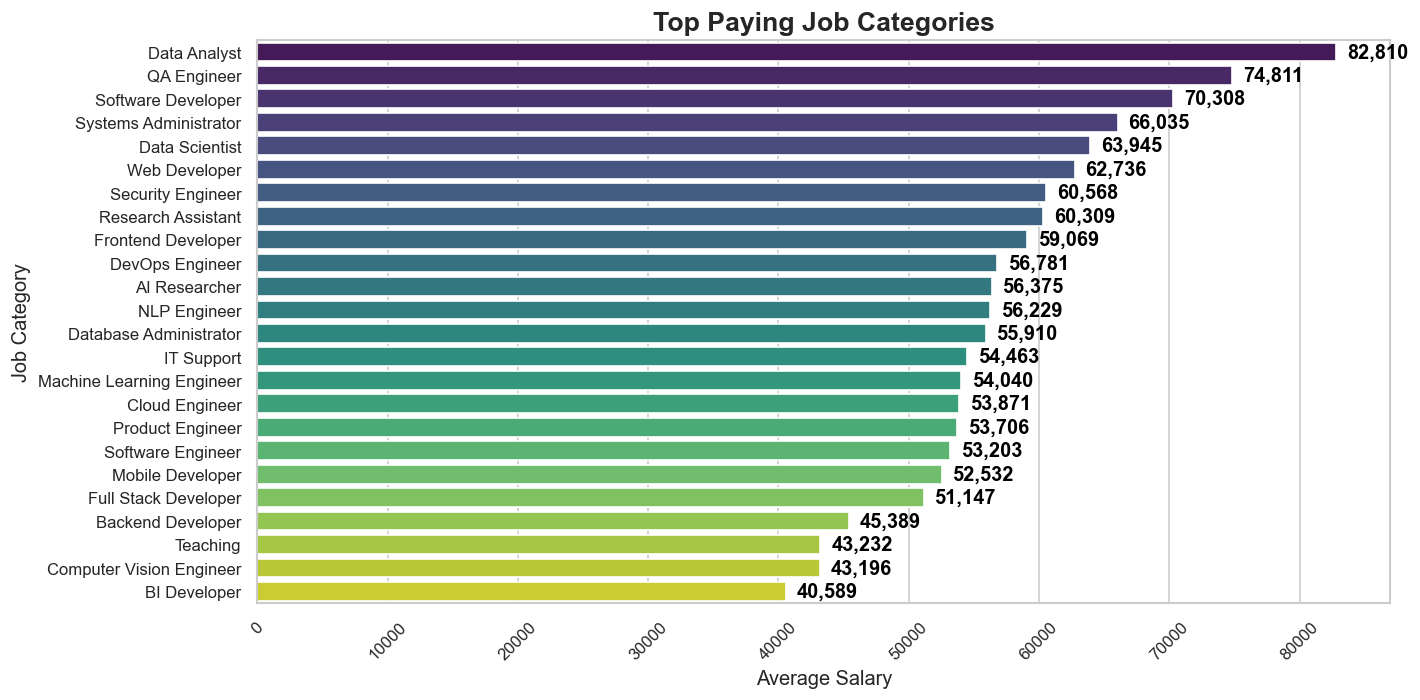

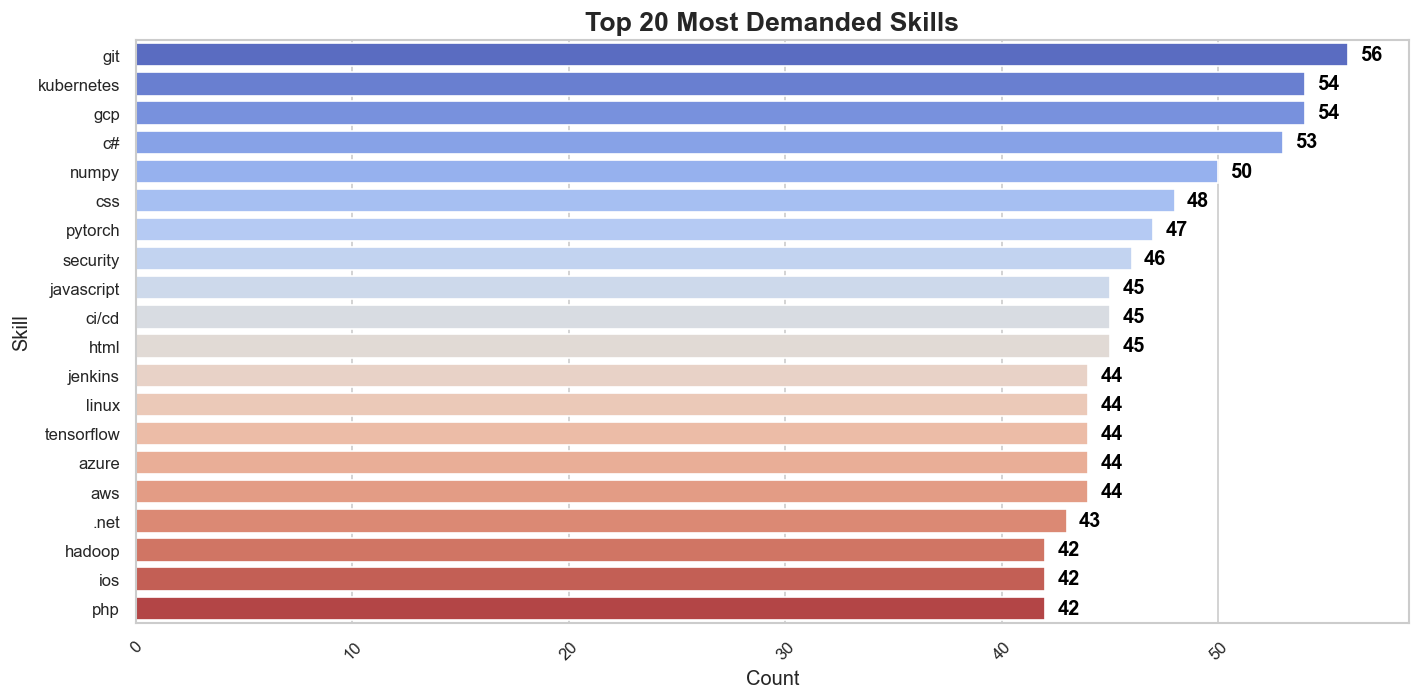

In [4]:

salary_by_category = df.groupby("Category")['SalaryNum'].mean().sort_values(ascending=False)
draw_bar_chart(
    x=salary_by_category.values,
    y=salary_by_category.index,
    title="Top Paying Job Categories",
    xlabel="Average Salary",
    ylabel="Job Category",
    palette="viridis"
)

# ------------------------
# ANALYSIS 2: MOST DEMANDED SKILLS
# ------------------------
skill_count = skill_series.value_counts().head(20)
draw_bar_chart(
    x=skill_count.values,
    y=skill_count.index,
    title="Top 20 Most Demanded Skills",
    xlabel="Count",
    ylabel="Skill",
    palette="coolwarm"
)



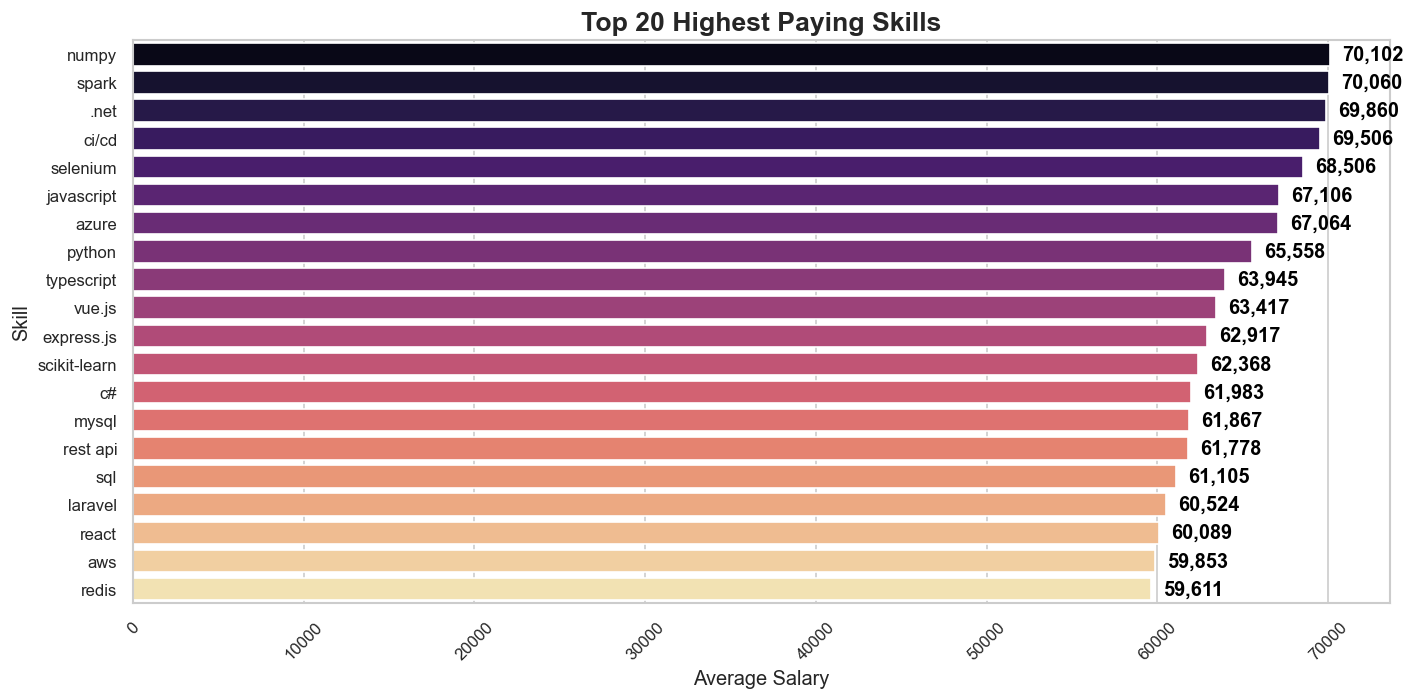

In [5]:
skill_salary_map = {}
for i, row in df.dropna(subset=['Skills']).iterrows():
    skills = row['Skills'].split(',')
    salary = row['SalaryNum']
    if np.isnan(salary):
        continue
    for s in skills:
        s = s.strip().lower()
        if s not in skill_salary_map:
            skill_salary_map[s] = []
        skill_salary_map[s].append(salary)

skill_salary_avg = {
    skill: np.mean(values)
    for skill, values in skill_salary_map.items()
    if len(values) >= 2
}
skill_salary_sorted = pd.Series(skill_salary_avg).sort_values(ascending=False).head(20)
draw_bar_chart(
    x=skill_salary_sorted.values,
    y=skill_salary_sorted.index,
    title="Top 20 Highest Paying Skills",
    xlabel="Average Salary",
    ylabel="Skill",
    palette="magma"
)



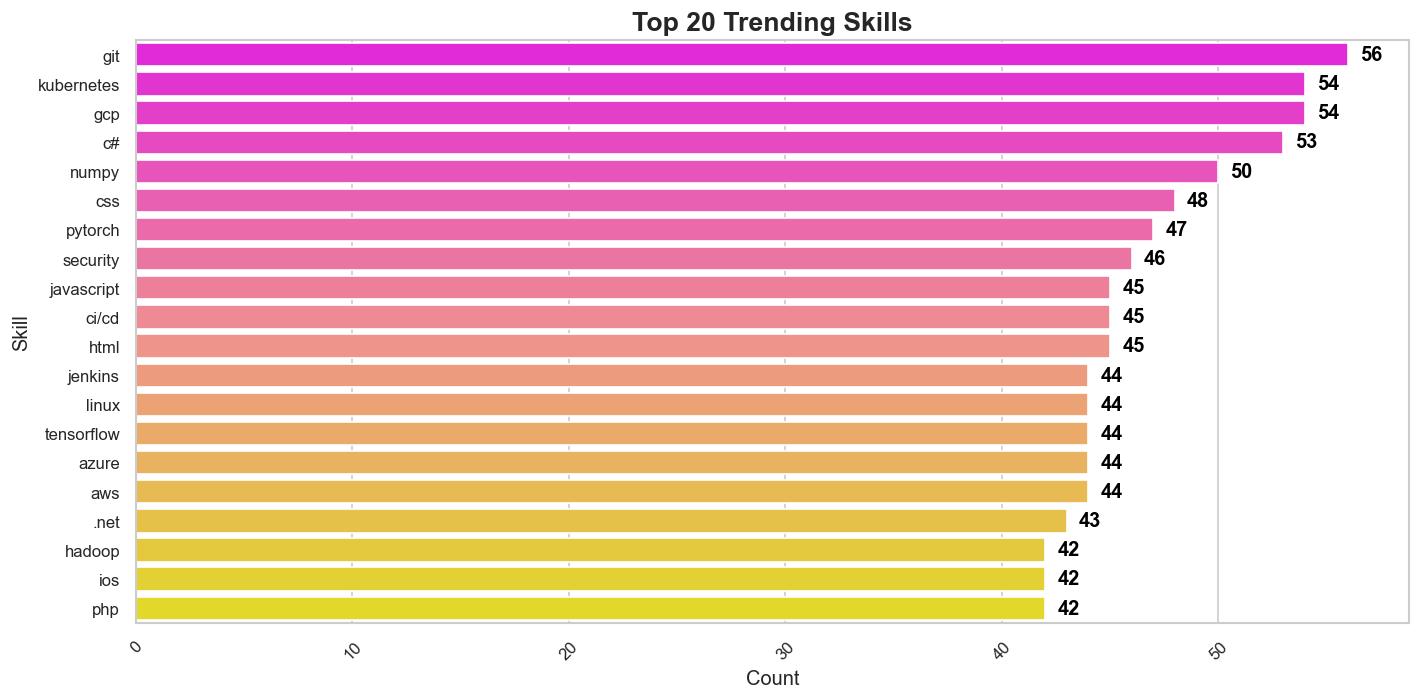

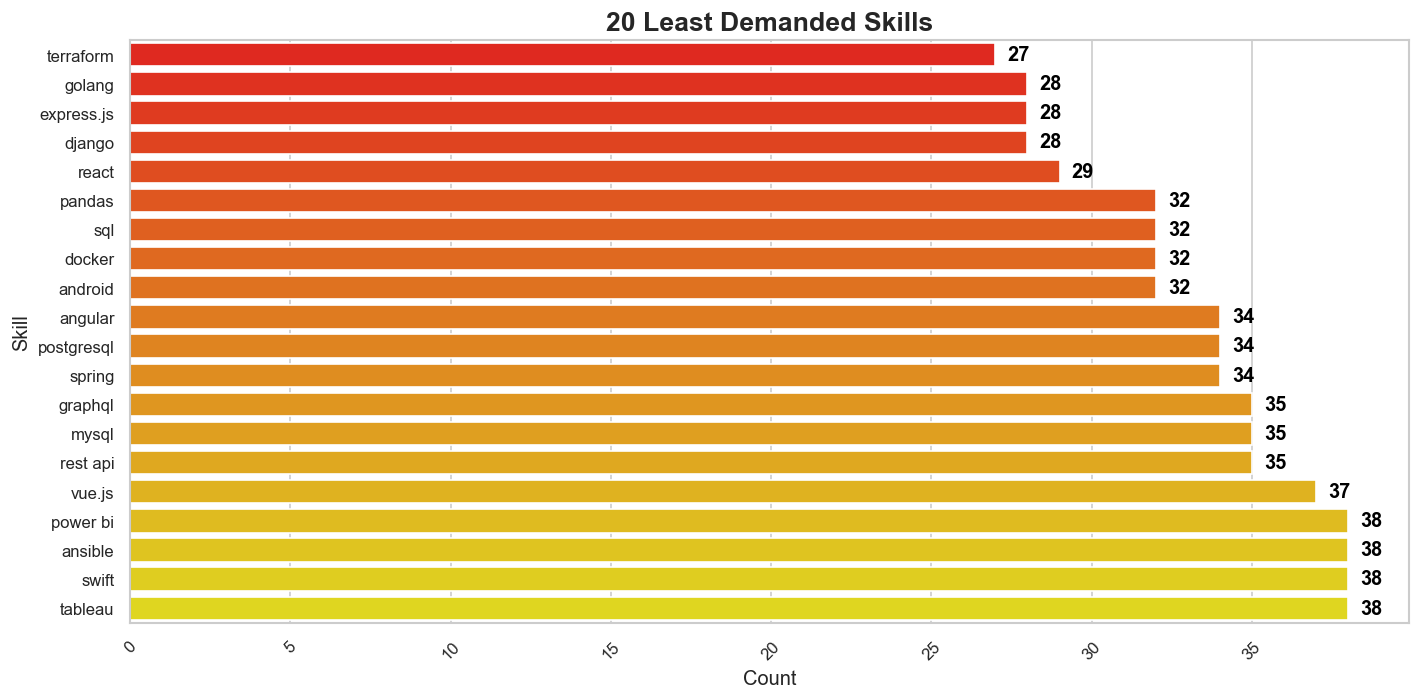

In [6]:
trending_skills = skill_series.value_counts().sort_values(ascending=False)
draw_bar_chart(
    x=trending_skills.head(20).values,
    y=trending_skills.head(20).index,
    title="Top 20 Trending Skills",
    xlabel="Count",
    ylabel="Skill",
    palette="spring"
)

# ------------------------
# ANALYSIS 5: DECLINING SKILLS
# ------------------------
declining_skills = skill_series.value_counts().sort_values().head(20)
draw_bar_chart(
    x=declining_skills.values,
    y=declining_skills.index,
    title="20 Least Demanded Skills",
    xlabel="Count",
    ylabel="Skill",
    palette="autumn"
)



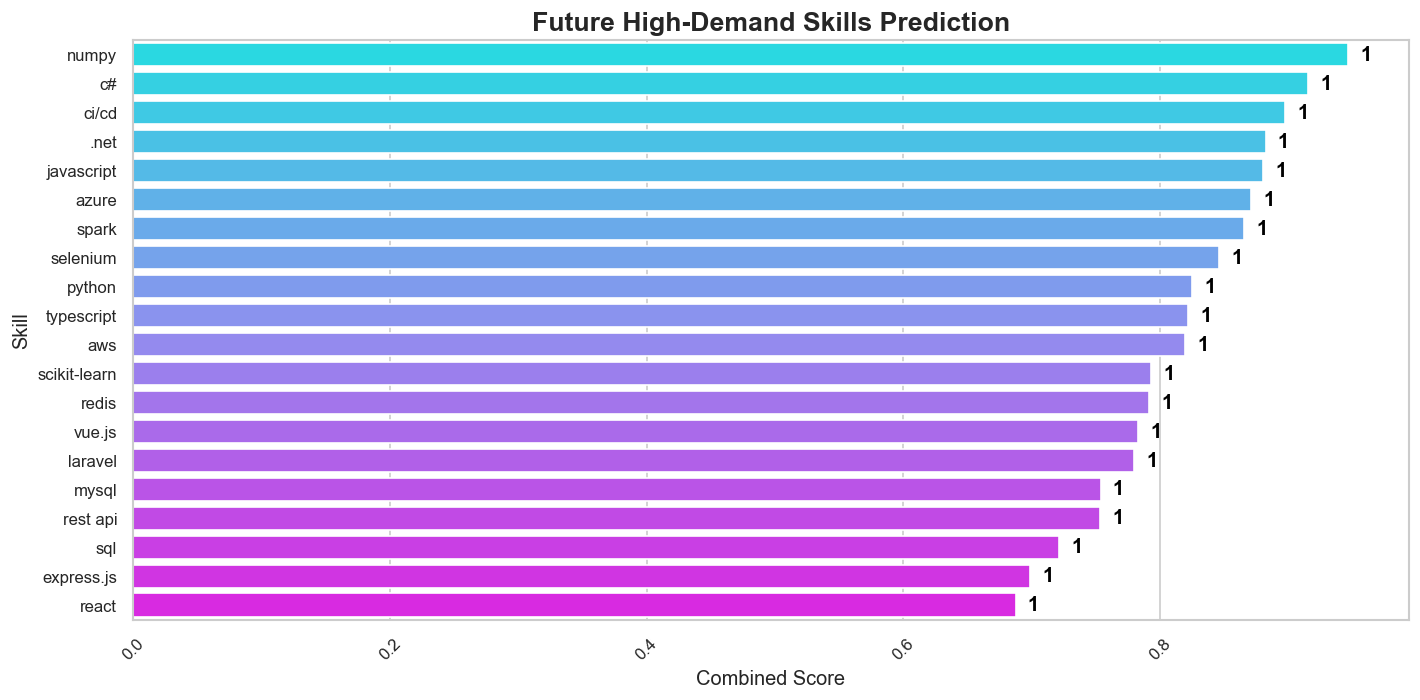


✔ Job Analysis Completed Successfully (No Emoji, No Error)!


In [7]:
combined_score = (
    (trending_skills / trending_skills.max()) * 0.5 +
    (skill_salary_sorted / skill_salary_sorted.max()).fillna(0) * 0.5
)
future_prediction = combined_score.sort_values(ascending=False).head(20)
draw_bar_chart(
    x=future_prediction.values,
    y=future_prediction.index,
    title="Future High-Demand Skills Prediction",
    xlabel="Combined Score",
    ylabel="Skill",
    palette="cool"
)

print("\n✔ Job Analysis Completed Successfully (No Emoji, No Error)!")